**Inventory Replenishment Agent**

This notebook builds an automatic inventory agent that:
- Predicts future demand using a math formula called EWMA
- Figures out how much extra stock to keep as a safety cushion
- Runs a daily check to decide when to place new orders
- Tracks how well it did by measuring stockouts, fill rate, and total cost

---

**Design Document**

**Agent Goal**

The agent's main job is to keep costs as low as possible while still making sure customers can get what they order. It does this by predicting how much people will buy each day and automatically deciding when to reorder products before they run out.

**Agent Role**

| Aspect | Description |
|---|---|
| What it optimizes | Spend as little money as possible while still filling customer orders |
| How often it decides | Once per day, after checking if any orders arrived and selling to customers |
| What it decides | Either place a new order, or wait |

**Decision Inputs**

Each day, the agent looks at:
- How much stock is currently on the shelf
- How much stock is already on the way (ordered but not arrived yet)
- Its best guess for how much will sell today and how reliable that guess is
- How many days it takes for a new order to arrive
- The reorder point — the lowest safe amount of stock before it's time to order again
- A projection of how much stock will be left by the time a new order arrives

**Decision Outputs**

- **WAIT:** If there's enough stock to last until the next order arrives, do nothing — ordering now would just waste money on storage.
- **ORDER:** If stock is going to run dangerously low before the next order could arrive, place an order big enough to get back to a safe level. The order size is always rounded up to the minimum the supplier allows.

**Guardrails & Business Rules**

1. **Minimum order size:** The agent never orders less than the supplier's minimum. This avoids placing tiny, wasteful orders.
2. **Lead time awareness:** The agent always thinks ahead — it looks at what stock will look like days from now, not just today, so it doesn't wait too long to reorder.
3. **Safety stock:** The agent keeps a cushion of extra stock based on how unpredictable sales are. Products with stricter fill rate goals get a bigger cushion.
4. **No over-ordering:** The agent only orders exactly what's needed to get back to a safe level — it doesn't just fill the warehouse to the max every time.
5. **Balancing storage vs running out:** Products that are expensive to run out of get treated more carefully, even if that means paying more to store them. Cheap, slow-moving products get leaner stock levels to save money.

**Metrics Defined**

| Metric | What it means |
|---|---|
| Fill Rate | Out of everything customers tried to buy, what percentage did they actually get? |
| Stockout Days | How many days did we completely run out of a product? |
| Holding Cost | How much did it cost to store unsold inventory each day? |
| Stockout Cost | How much did it cost when we couldn't fill an order? |
| Total Cost | Everything added together — the overall score for how well the agent did |

**Ethics & Trust**

- **Customer trust:** When a product is out of stock, a real customer doesn't get what they paid for. The agent treats fill rate targets like a promise, not just a suggestion, because letting customers down has real consequences.
- **Transparency:** Every single decision the agent makes is written down in a daily log — what it saw, what it decided, and why. This means a human can always look back and check the agent's work.
- **Fairness:** Every product gets its own safety stock and fill rate goal. The agent doesn't sacrifice one product's service to save money on another.
- **Human control:** All the important settings — like how fast the forecast reacts, how much safety stock to keep, and minimum order sizes — can be changed by a person at any time. The agent follows the rules humans set; it doesn't make up its own.

## Step 1 — Install & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO
from scipy.stats import norm

pd.set_option('display.float_format', '{:.2f}'.format)
print('Libraries loaded ✅')

Libraries loaded ✅


## Step 2 — Generate / Load CSV Data

We generate three CSVs:
- **`sales.csv`** — daily demand per SKU
- **`inventory.csv`** — opening stock per SKU
- **`params.csv`** — policy & cost inputs per SKU

In [2]:
np.random.seed(42)

# ── Date range: 90 days ──────────────────────────────────────────────────────
dates = pd.date_range('2024-01-01', periods=90, freq='D')

# ── SKU demand profiles ──────────────────────────────────────────────────────
sku_profiles = {
    'SKU-A': {'mean': 20, 'std': 4},   # steady, low variability
    'SKU-B': {'mean': 50, 'std': 15},  # high demand, high variability
    'SKU-C': {'mean': 10, 'std': 3},   # slow mover
}

sales_rows = []
for date in dates:
    for sku, profile in sku_profiles.items():
        qty = max(0, int(np.random.normal(profile['mean'], profile['std'])))
        sales_rows.append({'date': date.date(), 'sku': sku, 'qty_sold': qty})

sales_df = pd.DataFrame(sales_rows)
sales_df.to_csv('sales.csv', index=False)

# ── Inventory ────────────────────────────────────────────────────────────────
inventory_data = """
sku,opening_stock
SKU-A,500
SKU-B,1000
SKU-C,200
"""
inventory_df = pd.read_csv(StringIO(inventory_data.strip()))
inventory_df.to_csv('inventory.csv', index=False)

# ── Policy & Cost Parameters ─────────────────────────────────────────────────
params_data = """
sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level
SKU-A,10.00,0.05,25.00,5,100,0.95
SKU-B,25.00,0.10,60.00,7,200,0.98
SKU-C,5.00,0.02,15.00,3,50,0.90
"""
params_df = pd.read_csv(StringIO(params_data.strip()))
params_df.to_csv('params.csv', index=False)

print('Sample sales data:')
display(sales_df.head(9))
print('\nInventory:')
display(inventory_df)
print('\nParameters:')
display(params_df)

Sample sales data:


,date,sku,qty_sold
0,2024-01-01,SKU-A,21
1,2024-01-01,SKU-B,47
2,2024-01-01,SKU-C,11
3,2024-01-02,SKU-A,26
4,2024-01-02,SKU-B,46
5,2024-01-02,SKU-C,9
6,2024-01-03,SKU-A,26
7,2024-01-03,SKU-B,61
8,2024-01-03,SKU-C,8



Inventory:


,sku,opening_stock
0,SKU-A,500
1,SKU-B,1000
2,SKU-C,200



Parameters:


,sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level
0,SKU-A,10.00,0.05,25.00,5,100,0.95
1,SKU-B,25.00,0.10,60.00,7,200,0.98
2,SKU-C,5.00,0.02,15.00,3,50,0.90


## Step 3 — Load & Aggregate Daily Demand

Demand shape: (90, 3)


sku,SKU-A,SKU-B,SKU-C
date,,,
2024-01-01,21,47,11
2024-01-02,26,46,9
2024-01-03,26,61,8
2024-01-04,22,43,8
2024-01-05,20,21,4


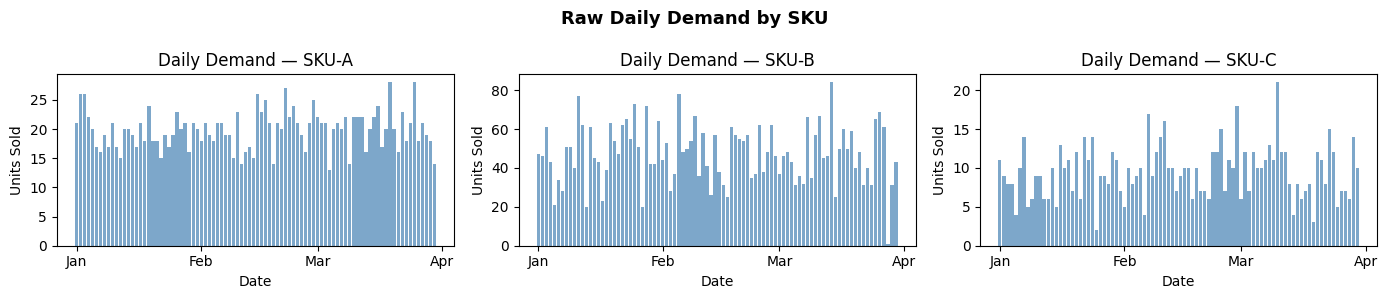

In [3]:
# Load CSVs
sales    = pd.read_csv('sales.csv',     parse_dates=['date'])
inventory = pd.read_csv('inventory.csv')
params    = pd.read_csv('params.csv')

# Pivot: rows = date, columns = SKU
demand = sales.pivot_table(index='date', columns='sku', values='qty_sold', aggfunc='sum').fillna(0)
demand.index = pd.DatetimeIndex(demand.index)

print('Demand shape:', demand.shape)
display(demand.head())

# ── Plot raw demand ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)
for ax, sku in zip(axes, demand.columns):
    ax.bar(demand.index, demand[sku], color='steelblue', alpha=0.7, width=0.8)
    ax.set_title(f'Daily Demand — {sku}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Units Sold')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.suptitle('Raw Daily Demand by SKU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — EWMA Demand Forecaster

We use **Exponentially Weighted Moving Average** with `alpha` controlling how much weight is given to recent observations.

$$\hat{d}_t = \alpha \cdot d_{t-1} + (1-\alpha) \cdot \hat{d}_{t-1}$$

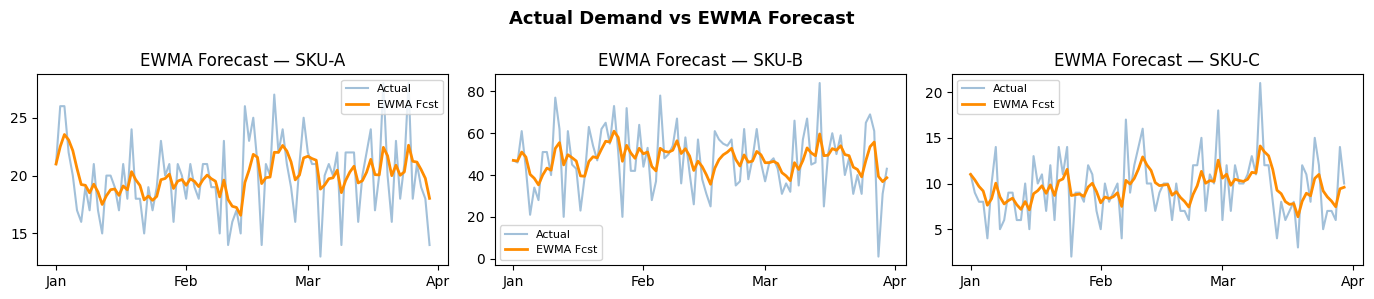

In [4]:
EWMA_ALPHA = 0.3   # smoothing factor — higher = more reactive to recent demand

def compute_ewma_forecast(demand_series: pd.Series, alpha: float = EWMA_ALPHA) -> pd.Series:
    """Returns one-step-ahead EWMA forecast aligned with demand_series index."""
    return demand_series.ewm(alpha=alpha, adjust=False).mean()

def compute_forecast_std(demand_series: pd.Series, forecast_series: pd.Series,
                          alpha: float = EWMA_ALPHA) -> pd.Series:
    """Rolling EWMA standard deviation of forecast errors."""
    errors = demand_series - forecast_series
    return errors.ewm(alpha=alpha, adjust=False).std().fillna(errors.std())

# Pre-compute for all SKUs
forecasts  = {}
forecast_stds = {}
for sku in demand.columns:
    forecasts[sku]      = compute_ewma_forecast(demand[sku])
    forecast_stds[sku]  = compute_forecast_std(demand[sku], forecasts[sku])

# ── Plot forecast vs actual ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, sku in zip(axes, demand.columns):
    ax.plot(demand.index, demand[sku],     label='Actual',   alpha=0.5, color='steelblue')
    ax.plot(demand.index, forecasts[sku],  label='EWMA Fcst', color='darkorange', linewidth=2)
    ax.set_title(f'EWMA Forecast — {sku}')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.suptitle('Actual Demand vs EWMA Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Safety Stock Calculation

Safety stock protects against demand uncertainty during the lead time:

$$\text{Safety Stock} = Z_{\text{sl}} \times \sigma_d \times \sqrt{L}$$

where $Z_{\text{sl}}$ is the z-score for the target service level, $\sigma_d$ is the forecast error std dev, and $L$ is lead time in days.

In [5]:
def compute_safety_stock(sigma_d: float, lead_time: int, service_level: float) -> float:
    """Safety stock = Z * sigma_d * sqrt(lead_time)"""
    z = norm.ppf(service_level)
    return z * sigma_d * np.sqrt(lead_time)

def compute_reorder_point(mean_daily_demand: float, lead_time: int, safety_stock: float) -> float:
    """Reorder point = (mean demand * lead time) + safety stock"""
    return mean_daily_demand * lead_time + safety_stock

# Build a params lookup dict for easy access
param_dict = params.set_index('sku').to_dict('index')

print(f"{'SKU':<8} {'Lead (d)':<10} {'Svc Lvl':<10} {'Z-score':<10} {'σ demand':<12} {'Safety Stock':<15} {'Reorder Pt':<12}")
print('-' * 77)
for sku in demand.columns:
    p  = param_dict[sku]
    lt = p['lead_time_days']
    sl = p['service_level']
    # Use last 30 days std for a realistic estimate
    sigma = forecast_stds[sku].iloc[-30:].mean()
    mu    = forecasts[sku].iloc[-30:].mean()
    ss    = compute_safety_stock(sigma, lt, sl)
    rop   = compute_reorder_point(mu, lt, ss)
    z     = norm.ppf(sl)
    print(f"{sku:<8} {lt:<10} {sl:<10.2f} {z:<10.2f} {sigma:<12.2f} {ss:<15.1f} {rop:<12.1f}")

SKU      Lead (d)   Svc Lvl    Z-score    σ demand     Safety Stock    Reorder Pt  
-----------------------------------------------------------------------------
SKU-A    5          0.95       1.64       2.80         10.3            112.1       
SKU-B    7          0.98       2.05       11.47        62.3            389.6       
SKU-C    3          0.90       1.28       2.83         6.3             35.8        


## Step 6 — Replenishment Agent Loop

Each day, the agent:
1. Receives any pending purchase orders (POs) that have arrived after their lead time.
2. Deducts actual demand from inventory (stockout if insufficient).
3. Recomputes the **reorder point** using latest EWMA forecast and forecast std dev.
4. Projects inventory at end of lead time: `projected = current_stock - forecasted_demand_over_LT`.
5. If `projected < reorder_point`, places a PO sized to bring projected stock to a target level.
6. Logs its reasoning every day.

In [6]:
def run_agent(demand_df, inventory_df, params_df, forecasts, forecast_stds,
              verbose=True, label='Agent'):
    """
    Simulate the replenishment agent over the full demand horizon.

    Returns
    -------
    results : dict[sku -> DataFrame]  — daily simulation ledger per SKU
    kpis    : dict[sku -> dict]       — summary KPIs per SKU
    """
    dates_list = sorted(demand_df.index)
    skus       = demand_df.columns.tolist()

    # ── Initialize state ──────────────────────────────────────────────────────
    stock      = {row['sku']: row['opening_stock'] for _, row in inventory_df.iterrows()}
    # pending_orders[sku] = list of (arrival_date, qty)
    pending    = {sku: [] for sku in skus}
    ledger     = {sku: [] for sku in skus}
    p          = params_df.set_index('sku').to_dict('index')

    for today in dates_list:
        for sku in skus:
            params_sku  = p[sku]
            lt          = params_sku['lead_time_days']
            moq         = params_sku['min_order_qty']
            sl          = params_sku['service_level']
            unit_cost   = params_sku['unit_cost']
            hold_cost   = params_sku['holding_cost_per_day']
            stock_cost  = params_sku['stockout_cost']

            # ── 1. Receive arriving POs ───────────────────────────────────────
            arrived_qty = 0
            remaining   = []
            for (arr_date, qty) in pending[sku]:
                if arr_date <= today:
                    arrived_qty += qty
                else:
                    remaining.append((arr_date, qty))
            pending[sku] = remaining
            stock[sku]   += arrived_qty

            # ── 2. Satisfy demand ─────────────────────────────────────────────
            actual_demand = demand_df.loc[today, sku]
            fulfilled     = min(stock[sku], actual_demand)
            stockout_units = max(0, actual_demand - stock[sku])
            stock[sku]    = max(0, stock[sku] - actual_demand)

            # ── 3. Update forecast & safety stock ────────────────────────────
            if today in forecasts[sku].index:
                mu_d    = forecasts[sku][today]
                sigma_d = forecast_stds[sku][today]
            else:
                mu_d    = forecasts[sku].iloc[-1]
                sigma_d = forecast_stds[sku].iloc[-1]

            ss  = compute_safety_stock(sigma_d, lt, sl)
            rop = compute_reorder_point(mu_d, lt, ss)

            # ── 4. Project inventory at end of lead time ──────────────────────
            # Subtract forecasted demand over lead time
            expected_in_transit = sum(qty for (arr, qty) in pending[sku])
            projected_stock     = stock[sku] + expected_in_transit - (mu_d * lt)

            # ── 5. Ordering decision ──────────────────────────────────────────
            order_qty   = 0
            order_reason = 'Hold — projected stock sufficient'

            if projected_stock < rop:
                # Order enough to reach target = rop + (mu_d * lt) + safety_stock buffer
                target     = mu_d * lt + ss * 1.5      # 1.5x safety buffer
                raw_order  = target - projected_stock
                order_qty  = max(moq, int(np.ceil(raw_order / moq) * moq))  # round up to MOQ
                arrival    = today + pd.Timedelta(days=lt)
                pending[sku].append((arrival, order_qty))
                order_reason = (
                    f'ORDER {order_qty} units '
                    f'(proj={projected_stock:.0f} < ROP={rop:.0f}, '
                    f'SS={ss:.0f}, μ={mu_d:.1f}/d, arrives {arrival.date()})'
                )

            # ── 6. Costs ──────────────────────────────────────────────────────
            daily_hold  = stock[sku] * hold_cost
            daily_stockout = stockout_units * stock_cost
            order_cost  = order_qty * unit_cost if order_qty > 0 else 0

            ledger[sku].append({
                'date':           today,
                'demand':         actual_demand,
                'fulfilled':      fulfilled,
                'stockout_units': stockout_units,
                'received':       arrived_qty,
                'order_qty':      order_qty,
                'closing_stock':  stock[sku],
                'forecast_mu':    mu_d,
                'safety_stock':   ss,
                'rop':            rop,
                'projected':      projected_stock,
                'holding_cost':   daily_hold,
                'stockout_cost':  daily_stockout,
                'order_cost':     order_cost,
                'total_cost':     daily_hold + daily_stockout + order_cost,
                'action':         order_reason,
            })

            if verbose:
                print(f"[{today.date()}] {sku} | Stock={stock[sku]:>5.0f} | "
                      f"Demand={actual_demand:>3.0f} | SO={stockout_units:>3.0f} | "
                      f"{order_reason}")

    # ── Convert ledgers to DataFrames ──────────────────────────────────────
    results = {sku: pd.DataFrame(ledger[sku]).set_index('date') for sku in skus}

    # ── KPI Summary ───────────────────────────────────────────────────────
    kpis = {}
    for sku in skus:
        df = results[sku]
        total_demand    = df['demand'].sum()
        total_fulfilled = df['fulfilled'].sum()
        fill_rate       = total_fulfilled / total_demand if total_demand > 0 else 0
        kpis[sku] = {
            'fill_rate':      fill_rate,
            'stockout_days':  (df['stockout_units'] > 0).sum(),
            'total_stockout_units': df['stockout_units'].sum(),
            'holding_cost':   df['holding_cost'].sum(),
            'stockout_cost':  df['stockout_cost'].sum(),
            'order_cost':     df['order_cost'].sum(),
            'total_cost':     df['total_cost'].sum(),
            'num_orders':     (df['order_qty'] > 0).sum(),
        }

    return results, kpis

print('Agent function defined ✅')

Agent function defined ✅


## Step 7 — Run the Agent & Print Daily Log

In [7]:
print('=' * 90)
print('INVENTORY REPLENISHMENT AGENT — DAILY LOG')
print('=' * 90)
agent_results, agent_kpis = run_agent(
    demand, inventory_df, params_df, forecasts, forecast_stds,
    verbose=True, label='Agent'
)

INVENTORY REPLENISHMENT AGENT — DAILY LOG
[2024-01-01] SKU-A | Stock=  479 | Demand= 21 | SO=  0 | Hold — projected stock sufficient
[2024-01-01] SKU-B | Stock=  953 | Demand= 47 | SO=  0 | Hold — projected stock sufficient
[2024-01-01] SKU-C | Stock=  189 | Demand= 11 | SO=  0 | Hold — projected stock sufficient
[2024-01-02] SKU-A | Stock=  453 | Demand= 26 | SO=  0 | Hold — projected stock sufficient
[2024-01-02] SKU-B | Stock=  907 | Demand= 46 | SO=  0 | Hold — projected stock sufficient
[2024-01-02] SKU-C | Stock=  180 | Demand=  9 | SO=  0 | Hold — projected stock sufficient
[2024-01-03] SKU-A | Stock=  427 | Demand= 26 | SO=  0 | Hold — projected stock sufficient
[2024-01-03] SKU-B | Stock=  846 | Demand= 61 | SO=  0 | Hold — projected stock sufficient
[2024-01-03] SKU-C | Stock=  172 | Demand=  8 | SO=  0 | Hold — projected stock sufficient
[2024-01-04] SKU-A | Stock=  405 | Demand= 22 | SO=  0 | Hold — projected stock sufficient
[2024-01-04] SKU-B | Stock=  803 | Demand= 43 | 

## Step 8 — Baseline: Naive Fixed-Reorder Policy

For comparison, we run a **baseline agent** that uses fixed reorder points (no adaptive forecasting) and orders fixed quantities — simulating a simple min/max inventory policy.

In [8]:
def run_baseline(demand_df, inventory_df, params_df, verbose=False):
    """Naive baseline: fixed ROP = mean_demand * lead_time, order = MOQ * 2."""
    dates_list = sorted(demand_df.index)
    skus       = demand_df.columns.tolist()
    stock      = {row['sku']: row['opening_stock'] for _, row in inventory_df.iterrows()}
    pending    = {sku: [] for sku in skus}
    ledger     = {sku: [] for sku in skus}
    p          = params_df.set_index('sku').to_dict('index')

    # Pre-compute fixed ROP from overall mean demand
    fixed_rop = {
        sku: demand_df[sku].mean() * p[sku]['lead_time_days'] * 1.2
        for sku in skus
    }

    for today in dates_list:
        for sku in skus:
            lt = p[sku]['lead_time_days']
            moq = p[sku]['min_order_qty']

            # Receive POs
            arrived_qty = 0
            remaining   = []
            for (arr_date, qty) in pending[sku]:
                if arr_date <= today:
                    arrived_qty += qty
                else:
                    remaining.append((arr_date, qty))
            pending[sku] = remaining
            stock[sku]   += arrived_qty

            actual_demand  = demand_df.loc[today, sku]
            stockout_units = max(0, actual_demand - stock[sku])
            fulfilled      = min(stock[sku], actual_demand)
            stock[sku]     = max(0, stock[sku] - actual_demand)

            order_qty = 0
            if stock[sku] <= fixed_rop[sku]:
                order_qty = moq * 2   # fixed order size
                pending[sku].append((today + pd.Timedelta(days=lt), order_qty))

            daily_hold     = stock[sku] * p[sku]['holding_cost_per_day']
            daily_stockout = stockout_units * p[sku]['stockout_cost']
            order_cost     = order_qty * p[sku]['unit_cost'] if order_qty > 0 else 0

            ledger[sku].append({
                'date': today, 'demand': actual_demand, 'fulfilled': fulfilled,
                'stockout_units': stockout_units, 'received': arrived_qty,
                'order_qty': order_qty, 'closing_stock': stock[sku],
                'holding_cost': daily_hold, 'stockout_cost': daily_stockout,
                'order_cost': order_cost,
                'total_cost': daily_hold + daily_stockout + order_cost,
            })

    results = {sku: pd.DataFrame(ledger[sku]).set_index('date') for sku in skus}
    kpis    = {}
    for sku in skus:
        df = results[sku]
        total_demand    = df['demand'].sum()
        total_fulfilled = df['fulfilled'].sum()
        kpis[sku] = {
            'fill_rate':           total_fulfilled / total_demand,
            'stockout_days':       (df['stockout_units'] > 0).sum(),
            'total_stockout_units': df['stockout_units'].sum(),
            'holding_cost':        df['holding_cost'].sum(),
            'stockout_cost':       df['stockout_cost'].sum(),
            'order_cost':          df['order_cost'].sum(),
            'total_cost':          df['total_cost'].sum(),
            'num_orders':          (df['order_qty'] > 0).sum(),
        }
    return results, kpis

baseline_results, baseline_kpis = run_baseline(demand, inventory_df, params_df)
print('Baseline simulation complete ✅')

Baseline simulation complete ✅


## Step 9 — KPI Summary Table

In [9]:
def kpi_table(baseline_kpis, agent_kpis):
    rows = []
    for sku in baseline_kpis:
        b = baseline_kpis[sku]
        a = agent_kpis[sku]
        rows.append({
            'SKU':                  sku,
            'Metric':               'Fill Rate (%)',
            'Baseline':             f"{b['fill_rate']*100:.1f}%",
            'Agent':                f"{a['fill_rate']*100:.1f}%",
            'Δ':                    f"{(a['fill_rate']-b['fill_rate'])*100:+.1f}pp",
        })
        rows.append({
            'SKU': sku, 'Metric': 'Stockout Days',
            'Baseline': b['stockout_days'], 'Agent': a['stockout_days'],
            'Δ': a['stockout_days'] - b['stockout_days'],
        })
        rows.append({
            'SKU': sku, 'Metric': 'Holding Cost ($)',
            'Baseline': f"${b['holding_cost']:.2f}",
            'Agent':    f"${a['holding_cost']:.2f}",
            'Δ':        f"${a['holding_cost']-b['holding_cost']:+.2f}",
        })
        rows.append({
            'SKU': sku, 'Metric': 'Stockout Cost ($)',
            'Baseline': f"${b['stockout_cost']:.2f}",
            'Agent':    f"${a['stockout_cost']:.2f}",
            'Δ':        f"${a['stockout_cost']-b['stockout_cost']:+.2f}",
        })
        rows.append({
            'SKU': sku, 'Metric': 'Total Cost ($)',
            'Baseline': f"${b['total_cost']:.2f}",
            'Agent':    f"${a['total_cost']:.2f}",
            'Δ':        f"${a['total_cost']-b['total_cost']:+.2f}",
        })
    return pd.DataFrame(rows).set_index(['SKU','Metric'])

kpi_df = kpi_table(baseline_kpis, agent_kpis)
print('\n📊 KPI Comparison: Baseline vs EWMA Agent')
display(kpi_df)


📊 KPI Comparison: Baseline vs EWMA Agent


Baseline       Agent           Δ
SKU   Metric                                               
SKU-A Fill Rate (%)          100.0%      100.0%      +0.0pp
      Stockout Days               0           0           0
      Holding Cost ($)     $2067.50     $862.50   $-1205.00
      Stockout Cost ($)       $0.00       $0.00      $+0.00
      Total Cost ($)      $22067.50   $15862.50   $-6205.00
SKU-B Fill Rate (%)          100.0%      100.0%      +0.0pp
      Stockout Days               0           0           0
      Holding Cost ($)    $10747.50    $5007.50   $-5740.00
      Stockout Cost ($)       $0.00       $0.00      $+0.00
      Total Cost ($)     $150747.50  $110007.50  $-40740.00
SKU-C Fill Rate (%)          100.0%      100.0%      +0.0pp
      Stockout Days               0           0           0
      Holding Cost ($)      $251.40     $126.40    $-125.00
      Stockout Cost ($)       $0.00       $0.00      $+0.00
      Total Cost ($)       $4751.40    $3876.40    $-875.00

## Step 10 — Visualisation: Inventory Levels, Stockouts & Orders

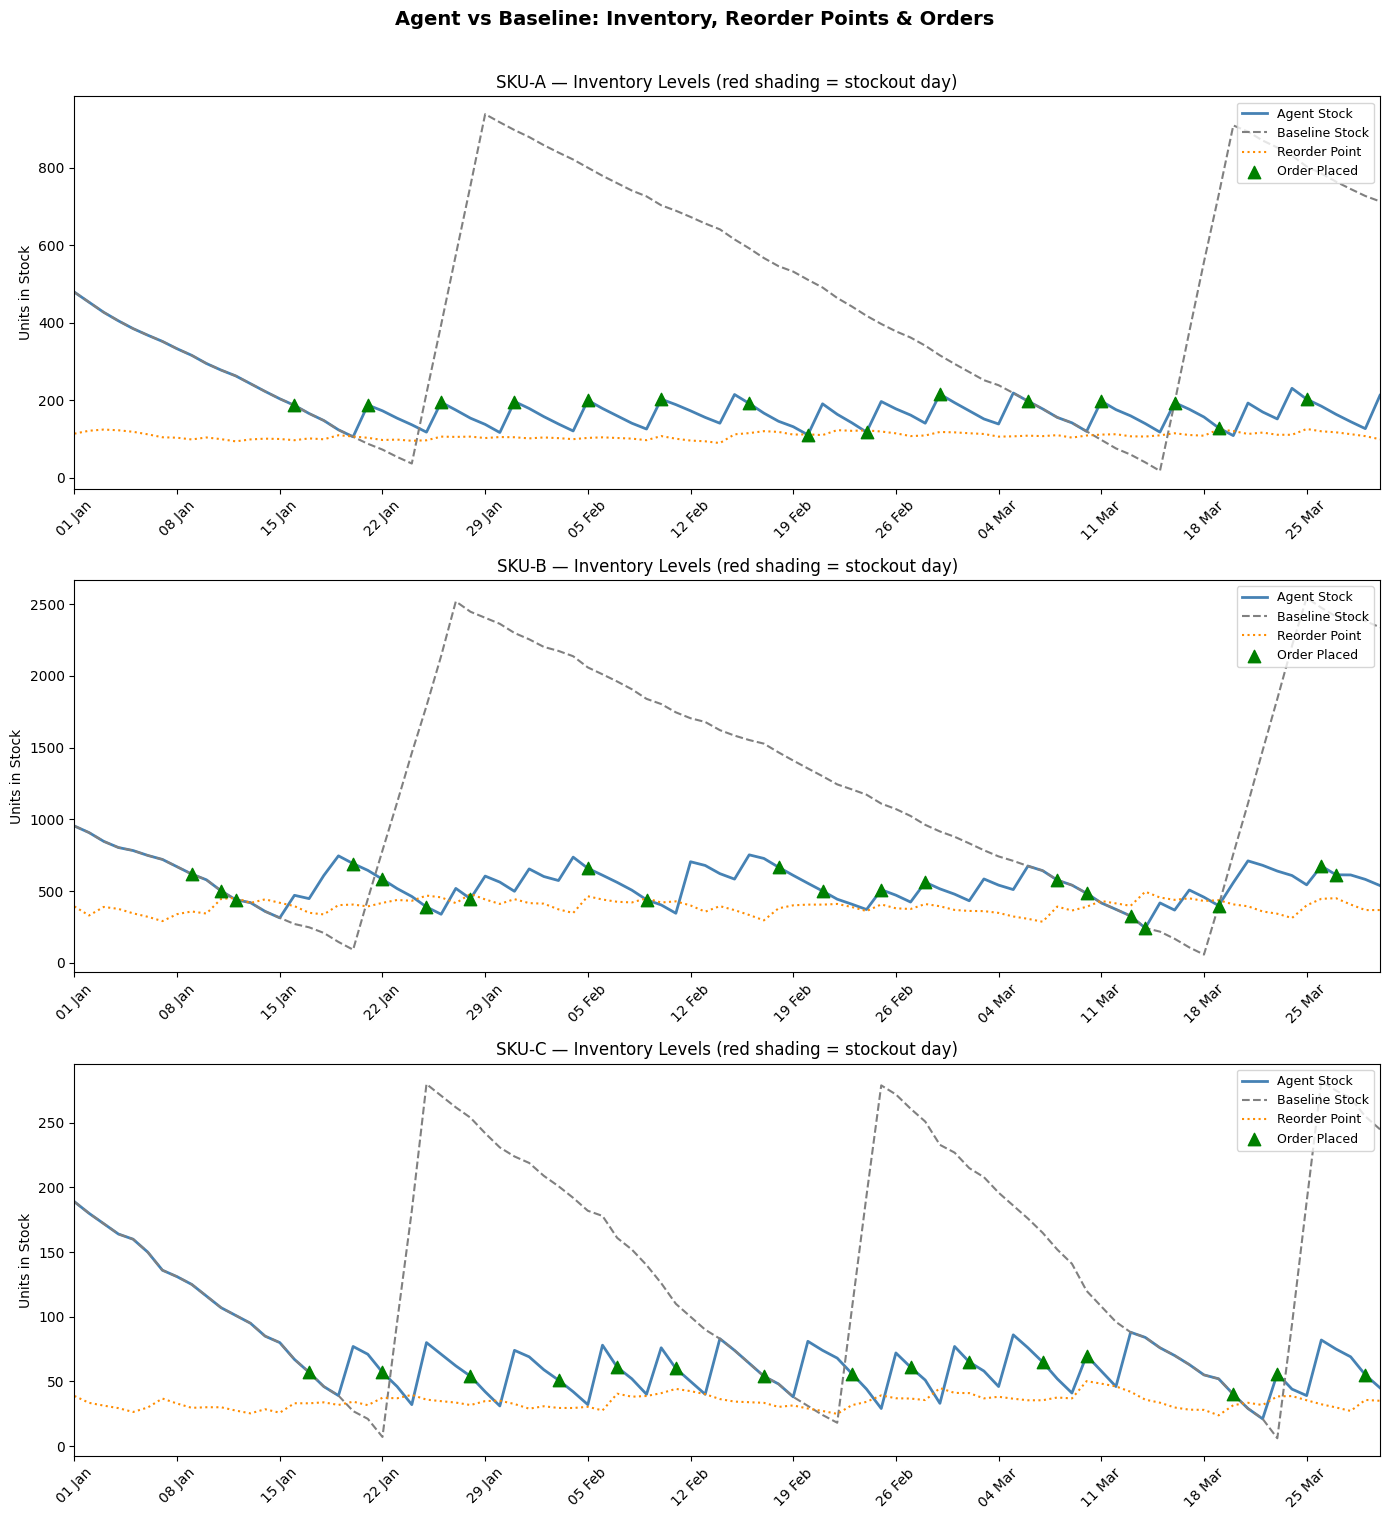

In [10]:
skus = demand.columns.tolist()
fig, axes = plt.subplots(len(skus), 1, figsize=(14, 5 * len(skus)))

for ax, sku in zip(axes, skus):
    agent_df    = agent_results[sku]
    baseline_df = baseline_results[sku]

    ax.plot(agent_df.index,    agent_df['closing_stock'],    label='Agent Stock',    color='steelblue',  linewidth=2)
    ax.plot(baseline_df.index, baseline_df['closing_stock'], label='Baseline Stock', color='gray',       linewidth=1.5, linestyle='--')
    ax.plot(agent_df.index,    agent_df['rop'],              label='Reorder Point',  color='darkorange', linewidth=1.5, linestyle=':')

    # Mark order placements
    order_days = agent_df[agent_df['order_qty'] > 0]
    ax.scatter(order_days.index, order_days['closing_stock'],
               marker='^', color='green', s=80, zorder=5, label='Order Placed')

    # Shade stockout days
    stockout_days = agent_df[agent_df['stockout_units'] > 0]
    for d in stockout_days.index:
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                   color='red', alpha=0.15)

    ax.set_title(f'{sku} — Inventory Levels (red shading = stockout day)', fontsize=12)
    ax.set_ylabel('Units in Stock')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlim(agent_df.index[0], agent_df.index[-1])

plt.suptitle('Agent vs Baseline: Inventory, Reorder Points & Orders', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 11 — Cost Breakdown Chart

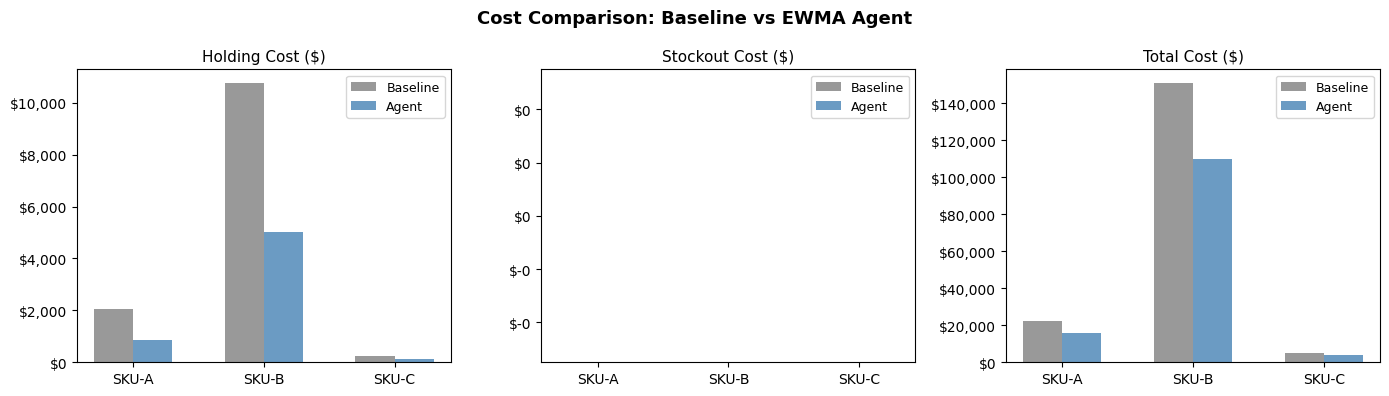

In [11]:
skus = demand.columns.tolist()
x    = np.arange(len(skus))
w    = 0.3

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cost_keys  = ['holding_cost', 'stockout_cost', 'total_cost']
cost_labels = ['Holding Cost ($)', 'Stockout Cost ($)', 'Total Cost ($)']

for ax, key, label in zip(axes, cost_keys, cost_labels):
    b_vals = [baseline_kpis[s][key] for s in skus]
    a_vals = [agent_kpis[s][key]    for s in skus]
    ax.bar(x - w/2, b_vals, width=w, label='Baseline', color='gray',      alpha=0.8)
    ax.bar(x + w/2, a_vals, width=w, label='Agent',    color='steelblue', alpha=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(skus)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}'))

plt.suptitle('Cost Comparison: Baseline vs EWMA Agent', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12 — Fill Rate Summary

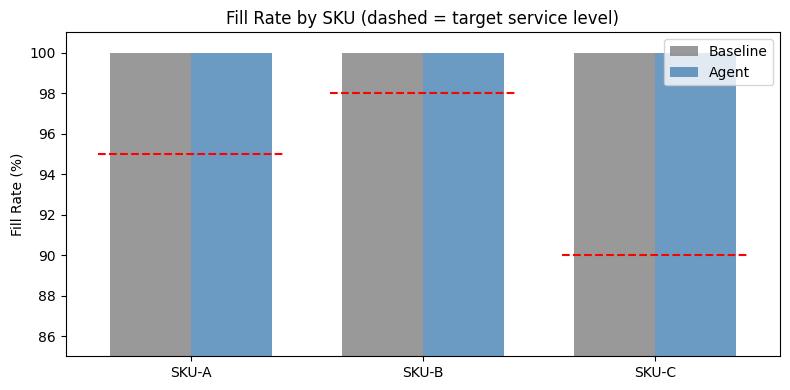


✅ Simulation Complete!

Fill Rate Summary:
  SKU-A: Agent=100.0%  Target=95%  ✅
  SKU-B: Agent=100.0%  Target=98%  ✅
  SKU-C: Agent=100.0%  Target=90%  ✅


In [12]:
skus = demand.columns.tolist()
x = np.arange(len(skus))
w = 0.35

b_fill = [baseline_kpis[s]['fill_rate'] * 100 for s in skus]
a_fill = [agent_kpis[s]['fill_rate'] * 100    for s in skus]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, b_fill, width=w, label='Baseline', color='gray',      alpha=0.8)
ax.bar(x + w/2, a_fill, width=w, label='Agent',    color='steelblue', alpha=0.8)

# Target service level lines
for i, sku in enumerate(skus):
    target = params_df.set_index('sku').loc[sku, 'service_level'] * 100
    ax.hlines(target, i - 0.4, i + 0.4, colors='red', linestyles='dashed', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(skus)
ax.set_ylabel('Fill Rate (%)')
ax.set_ylim(85, 101)
ax.set_title('Fill Rate by SKU (dashed = target service level)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('\n✅ Simulation Complete!')
print('\nFill Rate Summary:')
for sku in skus:
    target = params_df.set_index('sku').loc[sku, 'service_level'] * 100
    a_fr   = agent_kpis[sku]['fill_rate'] * 100
    met    = '✅' if a_fr >= target else '⚠️'
    print(f"  {sku}: Agent={a_fr:.1f}%  Target={target:.0f}%  {met}")

Here it is:

---

**Step 13 — Trade-off Reflection**

**Inventory vs Service Level: The Core Tension**

Every inventory system has one big challenge: if you stock too much, you waste money storing things. If you stock too little, you run out and customers can't get what they need. The agent has to find the sweet spot in the middle every single day.

**1. Holding Cost vs Stockout Cost**

The agent is constantly balancing two problems:

- **Holding cost** is like paying rent for stuff sitting on a shelf. Every day a product just sits there, it costs money — for storage space, and because that money could've been used for something else.
- **Stockout cost** happens when you completely run out of a product. This is a bigger, sudden problem — customers get upset, you might lose their business, and you might have to pay extra to rush an emergency order.

For SKU-B, which sells a lot and is unpredictable, the agent keeps extra stock on hand just in case, even though that costs more to store. For SKU-C, which sells slowly and isn't that critical, the agent keeps less stock around to save money.

**2. Service Level Target vs Working Capital**

You might think that going from a 95% to a 99% fill rate only needs 4% more inventory — but that's not how it works. Because of math (the shape of a bell curve), that small jump actually needs about 42% more safety stock. So companies have to ask themselves: how much money are we willing to tie up in extra inventory just to fill those last few orders?

**3. Forecast Accuracy vs Reactivity (Alpha Trade-off)**

The `alpha` setting controls how quickly the agent reacts to changes in demand:

- **High alpha (like 0.5):** The agent reacts fast to sudden spikes in demand — but it might panic-order too much during a short-term rush, leaving you with a pile of stuff nobody ends up buying.
- **Low alpha (like 0.1):** The agent stays calm and doesn't overreact — but it might be too slow to notice when demand has genuinely gone up, leading to stockouts.

The default of 0.3 tries to balance both, but ideally you'd fine-tune it for each product based on how reliable past forecasts have been.

**4. Lead Time Amplifies Everything**

Lead time is how long it takes for an order to arrive. The longer that wait is, the more things can go wrong. SKU-B has a 7-day lead time, which means the agent has to predict demand 7 days into the future — and any mistake in that forecast gets multiplied across all 7 days. The single best way to reduce both costs and stockout risk at the same time is simply to get a faster supplier.

**Summary Table**

| Lever | Increase → | Effect on Holding Cost | Effect on Stockout Risk |
|---|---|---|---|
| Service level target | ↑ | ↑ More safety stock | ↓ Fewer stockouts |
| EWMA alpha | ↑ | ↑ More reactive ordering | ↓ Responds faster to surges |
| Lead time | ↑ | ↑ More safety stock needed | ↑ More exposure to variability |
| Min order qty | ↑ | ↑ Lumpier, larger stock | ↓ Fewer but larger replenishments |
| Stockout cost | ↑ | ↑ Agent holds more buffer | ↓ Agent is more conservative |

How Would This Agent Work in the Real World?

Right now, the agent runs in this notebook on your computer. But a real store or warehouse would need it running automatically every day, even while you sleep. Here's how that would work.
Cloud Deployment (Running It Automatically)
Instead of opening a notebook manually, the agent would be uploaded to the cloud — basically a powerful computer on the internet that never turns off. Every morning, a built-in timer would wake the agent up, run it automatically, and send any new orders to the warehouse system. This is similar to how your phone automatically checks for new messages in the background — you don't have to do anything. The sales data would no longer live in CSV files. It would be stored in a big online database, and the agent would pull yesterday's sales numbers from there each morning before making its decisions.
Monitoring (Making Sure It's Working)
Even a good agent can make mistakes, so someone needs to keep an eye on it. We would set up automatic warnings — similar to a smoke alarm — that send a text or email to a manager if something goes wrong. For example, if customers are not getting their orders, an alert goes out immediately. If the agent's demand forecast is way off for several days in a row, a human is notified to check if something unusual is happening like a holiday or a viral trend. Every decision the agent makes is saved in a log, so managers can look back and see exactly why it ordered what it ordered on any given day.
Reliability (What If Something Goes Wrong?)
Things break sometimes — internet goes out, data is missing, servers crash. If today's sales data is missing, the agent uses its most recent forecast instead of guessing zero, so it doesn't accidentally under-order. If an order fails to send, the agent tries again a few times before giving up and alerting a human. The agent also double-checks that it hasn't already placed the same order today before submitting, so it never accidentally orders the same thing twice.
Cost Controls (Preventing Runaway Spending)
We don't want the agent to go overboard and order way too much. Each product has a maximum stock limit — the agent can never order more than what fits in the warehouse. The total value of all inventory is tracked daily, and if it gets too high, a manager is alerted. If the agent already placed an order for a product recently and it hasn't arrived yet, it waits before placing another one — no need to double up.